# ❤️ Heart Disease Prediction — ANFIS (SANFIS)
**Cleveland Heart Disease Dataset | Steps: EDA → Feature Selection → Preprocessing → SANFIS Training**

In [71]:
!pip install sanfis torch scikit-learn pandas numpy matplotlib seaborn
print("All packages installed!")

All packages installed!


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

print("✅ Imports successful!")


✅ Imports successful!


In [73]:
import pandas as pd
import os

if os.path.exists("dataset.csv"):
    df = pd.read_csv("dataset.csv")
    print("dataset.csv load ho gaya!")
else:
    print("dataset.csv file nahi mili!")

print(f"\nShape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

df.head()

dataset.csv load ho gaya!

Shape: (270, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


In [74]:
print("=== Missing values ===")
print(df.isnull().sum())

print("\n=== Descriptive statistics ===")
df.describe()


=== Missing values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== Descriptive statistics ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,2.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,0.585185,0.670370,1.822222,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,0.959140,0.497827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000
50%,55.000000,1.000000,2.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,2.000000,3.000000,3.000000,1.000000


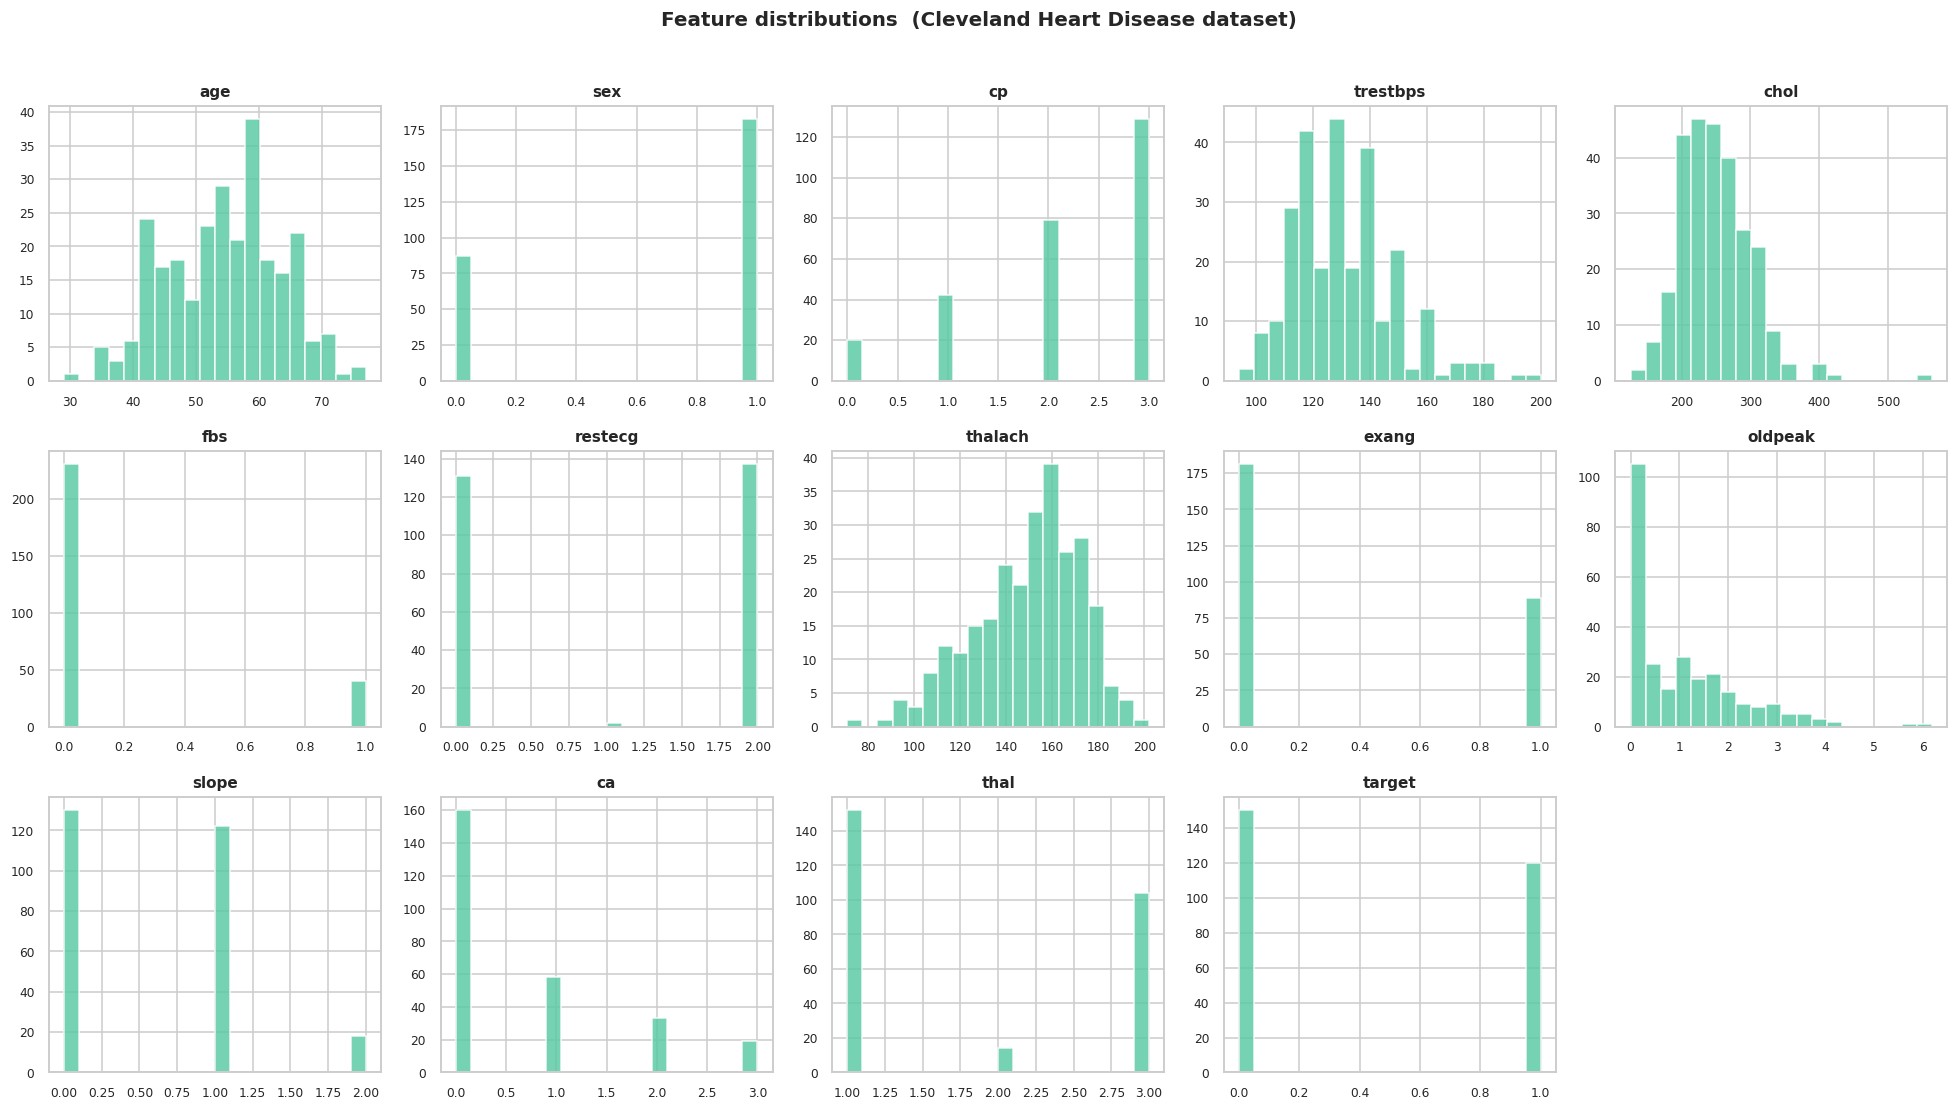

In [75]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col].dropna(), bins=20, color="#5DCAA5",
                 edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].tick_params(labelsize=8)

# Agar columns 15 se kam hain to baki axes hide karo
for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature distributions  (Cleveland Heart Disease dataset)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


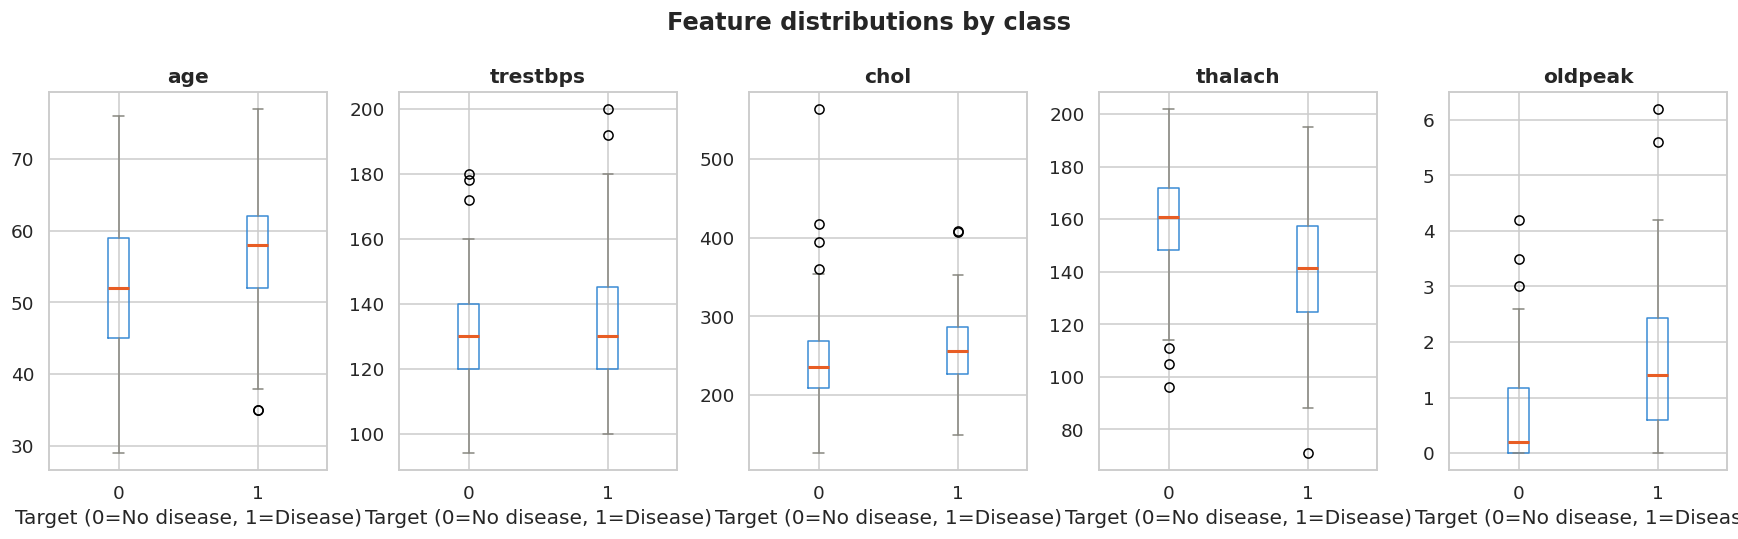

In [76]:
target_col = "target"

continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(1, len(continuous_cols), figsize=(16, 5))

for ax, col in zip(axes, continuous_cols):
    df.boxplot(column=col, by=target_col, ax=ax,
               boxprops=dict(color="#3B8BD4"),
               medianprops=dict(color="#E85D24", linewidth=2),
               whiskerprops=dict(color="#888780"),
               capprops=dict(color="#888780"))
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Target (0=No disease, 1=Disease)")

plt.suptitle("Feature distributions by class", fontweight="bold")
plt.tight_layout()
plt.show()


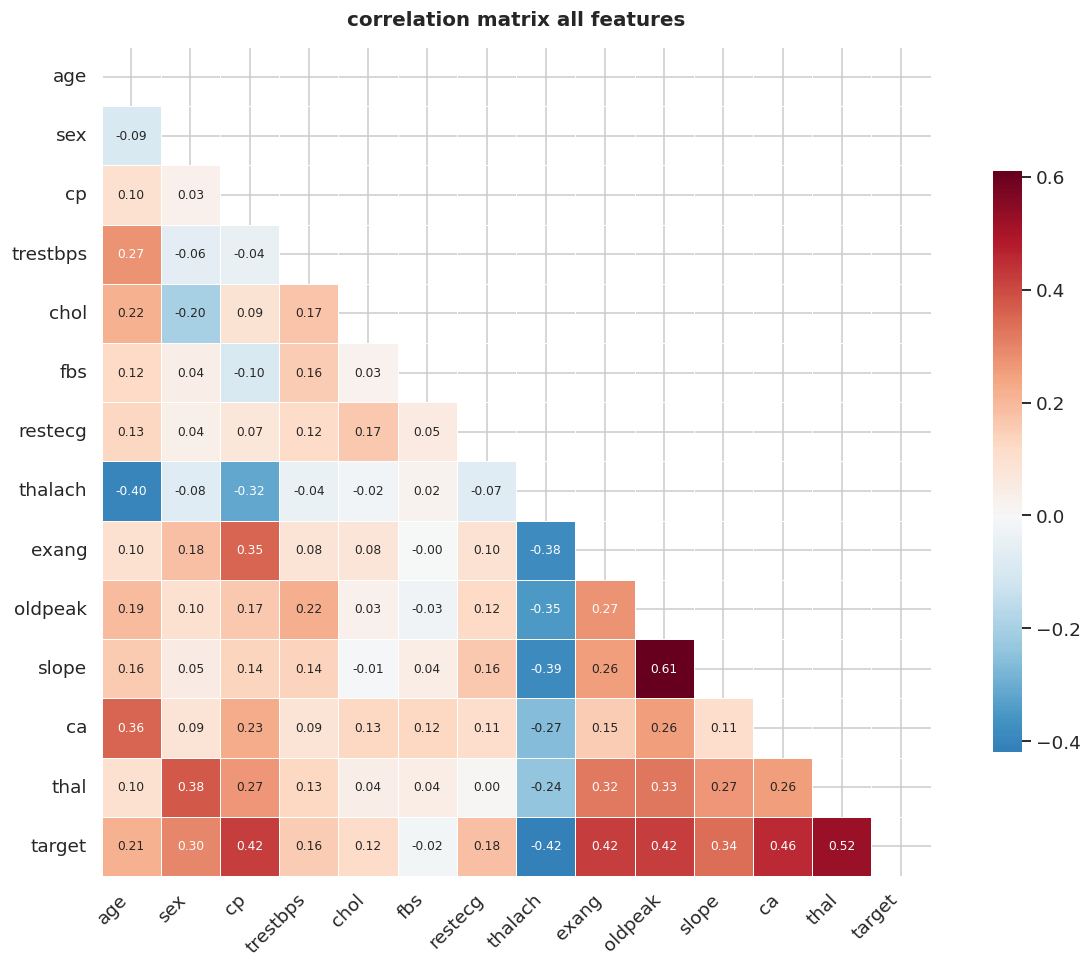

In [77]:
plt.figure(figsize=(12, 9))

corr_matrix = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7},
    annot_kws={"size": 8}
)

plt.title("correlation matrix all features",
          fontsize=13, fontweight="bold", pad=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Class distribution:
 target
0    150
1    120
Name: count, dtype: int64

Ratio: 150:120  (55.6% / 44.4%)


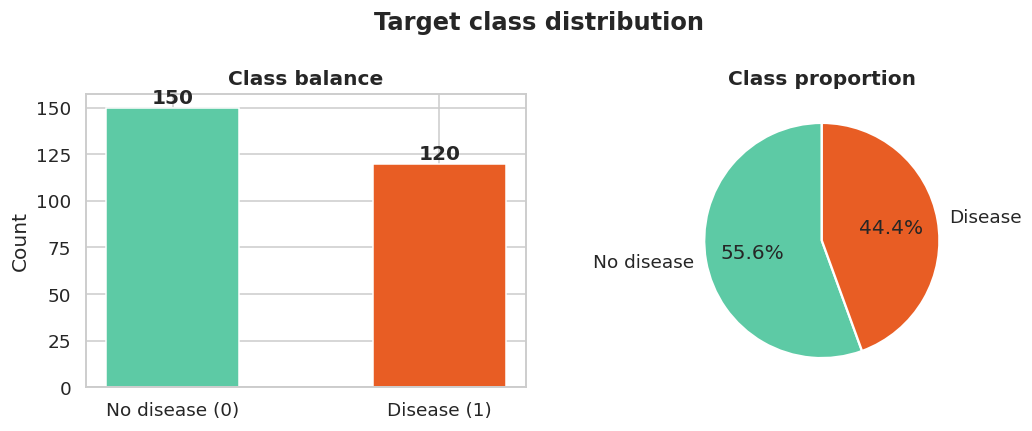

In [78]:
class_counts = df[target_col].value_counts().sort_index()
print("Class distribution:\n", class_counts)
print(f"\nRatio: {class_counts[0]}:{class_counts[1]}  "
      f"({class_counts[0]/len(df)*100:.1f}% / {class_counts[1]/len(df)*100:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(["No disease (0)", "Disease (1)"], class_counts.values,
        color=["#5DCAA5", "#E85D24"], edgecolor="white", width=0.5)
ax1.set_title("Class balance", fontweight="bold")
ax1.set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    ax1.text(i, v + 2, str(v), ha="center", fontweight="bold")

ax2.pie(class_counts.values,
        labels=["No disease", "Disease"],
        colors=["#5DCAA5", "#E85D24"],
        autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax2.set_title("Class proportion", fontweight="bold")

plt.suptitle("Target class distribution", fontweight="bold")
plt.tight_layout()
plt.show()


## 🔍 Step 2: Feature Selection

=== Absolute Pearson correlation with target ===
thal        0.524225
ca          0.455336
exang       0.419303
thalach     0.418514
oldpeak     0.417967
cp          0.417436
slope       0.337616
sex         0.297721
age         0.212322
restecg     0.182091
trestbps    0.155383
chol        0.118021
fbs         0.016319


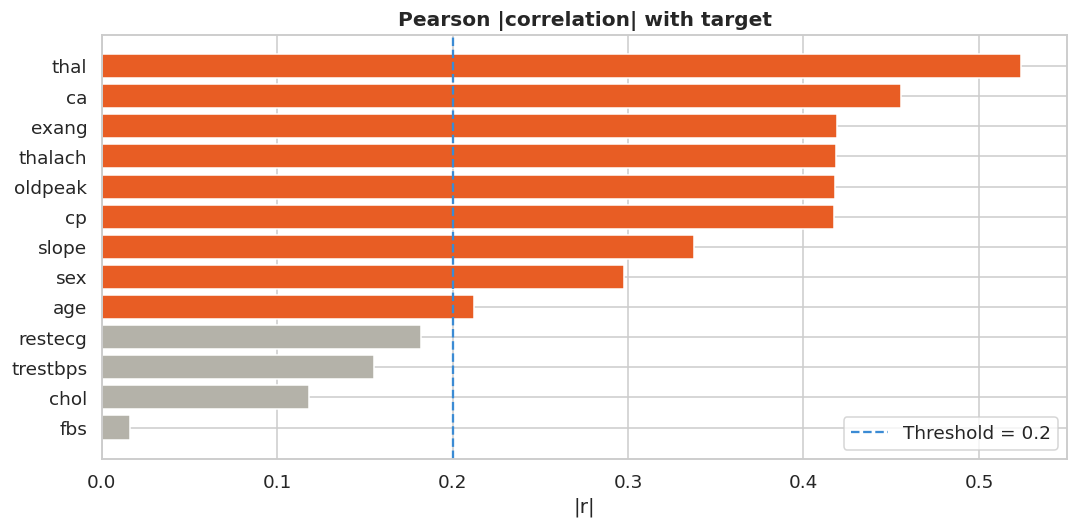

In [79]:
X = df.drop(columns=[target_col])
y = df[target_col]

# FIX: numeric_only=True
target_corr = df.corr(numeric_only=True)[target_col].drop(target_col).abs().sort_values(ascending=False)

print("=== Absolute Pearson correlation with target ===")
print(target_corr.to_string())

plt.figure(figsize=(10, 5))
colors = ["#E85D24" if v >= 0.2 else "#B4B2A9" for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor="white")
plt.axvline(0.2, color="#3B8BD4", linestyle="--", linewidth=1.5, label="Threshold = 0.2")
plt.title("Pearson |correlation| with target", fontweight="bold")
plt.xlabel("|r|")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


=== Mutual Information scores ===
exang       0.141007
thal        0.129618
cp          0.123015
ca          0.109860
oldpeak     0.093936
thalach     0.072105
chol        0.068068
slope       0.054391
sex         0.030694
fbs         0.007946
age         0.000822
restecg     0.000027
trestbps    0.000000


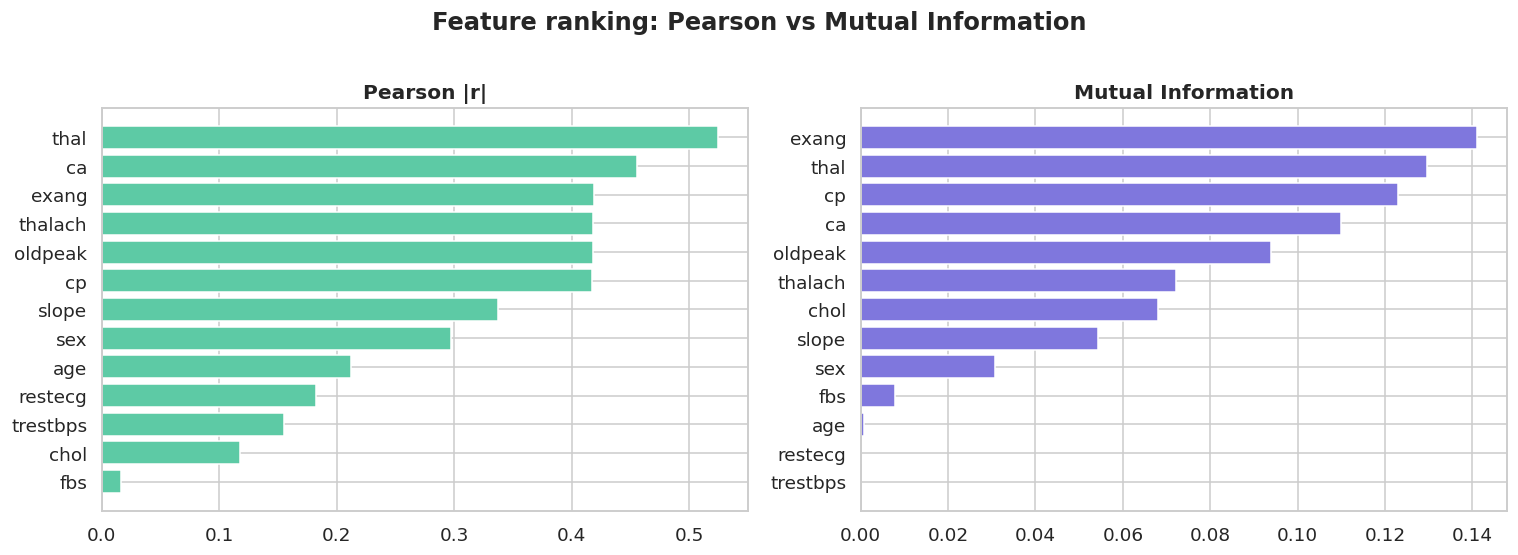

In [80]:
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("=== Mutual Information scores ===")
print(mi_series.to_string())

comparison_df = pd.DataFrame({
    "Pearson |r|": target_corr,
    "Mutual Information": mi_series
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes,
                           ["Pearson |r|", "Mutual Information"],
                           ["#5DCAA5", "#7F77DD"]):
    sorted_vals = comparison_df[col].sort_values(ascending=False)
    ax.barh(sorted_vals.index, sorted_vals.values, color=color, edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.invert_yaxis()

plt.suptitle("Feature ranking: Pearson vs Mutual Information",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [81]:
# Normalize to [0, 1]
comparison_df["Pearson_norm"] = (
    (comparison_df["Pearson |r|"] - comparison_df["Pearson |r|"].min()) /
    (comparison_df["Pearson |r|"].max() - comparison_df["Pearson |r|"].min())
)
comparison_df["MI_norm"] = (
    (comparison_df["Mutual Information"] - comparison_df["Mutual Information"].min()) /
    (comparison_df["Mutual Information"].max() - comparison_df["Mutual Information"].min())
)
comparison_df["Combined score"] = (comparison_df["Pearson_norm"] + comparison_df["MI_norm"]) / 2
comparison_df = comparison_df.sort_values("Combined score", ascending=False)

print("=== Final feature ranking (combined score) ===")
print(comparison_df[["Pearson |r|", "Mutual Information", "Combined score"]].round(4).to_string())

selected_features = ["thal", "ca", "oldpeak", "thalach", "cp", "exang"]
dropped_features  = ["fbs"]

print(f"\n✓ Selected features: {selected_features}")
print(f"✗ Dropped features:  {dropped_features}")
print(f"\nReason to drop fbs: Pearson = {target_corr.get('fbs', 0):.4f}, "      f"MI = {mi_series.get('fbs', 0):.4f}")


=== Final feature ranking (combined score) ===
          Pearson |r|  Mutual Information  Combined score
thal           0.5242              0.1296          0.9596
exang          0.4193              0.1410          0.8967
cp             0.4174              0.1230          0.8311
ca             0.4553              0.1099          0.8217
oldpeak        0.4180              0.0939          0.7285
thalach        0.4185              0.0721          0.6516
slope          0.3376              0.0544          0.5092
sex            0.2977              0.0307          0.3859
chol           0.1180              0.0681          0.3415
age            0.2123              0.0008          0.1959
restecg        0.1821              0.0000          0.1633
trestbps       0.1554              0.0000          0.1369
fbs            0.0163              0.0079          0.0282

✓ Selected features: ['thal', 'ca', 'oldpeak', 'thalach', 'cp', 'exang']
✗ Dropped features:  ['fbs']

Reason to drop fbs: Pearson = 0.0163,

In [82]:
X_selected = df[selected_features].copy()
y_target   = df[target_col].copy()

print("Final feature matrix shape:", X_selected.shape)
print("Target vector shape:       ", y_target.shape)
print("\nFeature matrix preview:")
X_selected.head()


Final feature matrix shape: (270, 6)
Target vector shape:        (270,)

Feature matrix preview:


,thal,ca,oldpeak,thalach,cp,exang
0,1,3,2.4,109,3,0
1,3,0,1.6,160,2,0
2,3,0,0.3,141,1,0
3,3,1,0.2,105,3,1
4,1,1,0.2,121,1,1


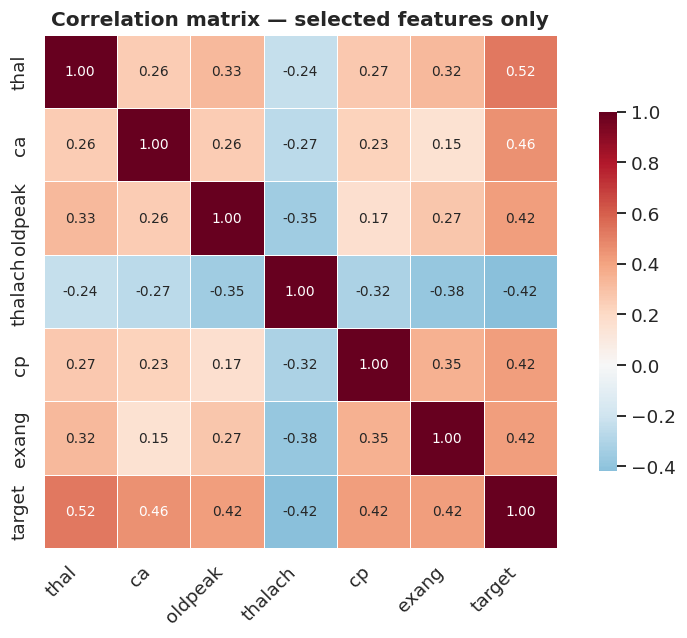

In [83]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    X_selected.assign(target=y_target).corr(numeric_only=True),
    annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.7}, annot_kws={"size": 9}
)
plt.title("Correlation matrix — selected features only", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 🧹 Step 3: Outlier Detection & Handling

In [84]:

continuous_features = ["oldpeak", "thalach"]

print("=" * 55)
print("IQR METHOD — OUTLIER DETECTION REPORT")
print("=" * 55)

outlier_indices = {}

for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_fence) | (df[col] > upper_fence)]
    outlier_indices[col] = outliers.index.tolist()

    print(f"\nFeature: {col}")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Normal range: [{lower_fence:.2f}, {upper_fence:.2f}]")
    print(f"  Outlier count: {len(outliers)} out of {len(df)}")
    print(f"  Percentage: {len(outliers)/len(df)*100:.1f}%")
    if len(outliers) > 0:
        print(f"  Outlier values: {sorted(outliers[col].values.tolist())}")


IQR METHOD — OUTLIER DETECTION REPORT

Feature: oldpeak
  Q1=0.00, Q3=1.60, IQR=1.60
  Normal range: [-2.40, 4.00]
  Outlier count: 4 out of 270
  Percentage: 1.5%
  Outlier values: [4.2, 4.2, 5.6, 6.2]

Feature: thalach
  Q1=133.00, Q3=166.00, IQR=33.00
  Normal range: [83.50, 215.50]
  Outlier count: 1 out of 270
  Percentage: 0.4%
  Outlier values: [71]


In [85]:
print("OUTLIER PATIENTS KA MEDICAL PROFILE")
print("=" * 60)

all_outlier_idx = set()
for col, idxs in outlier_indices.items():
    all_outlier_idx.update(idxs)

if len(all_outlier_idx) > 0:
    outlier_patients = df.loc[list(all_outlier_idx),
                               selected_features + [target_col]]
    print(f"\nTotal unique outlier patients: {len(all_outlier_idx)}")

    print(f"Inme se jinhe heart disease hai: "
          f"{outlier_patients[target_col].sum()} "
          f"({outlier_patients[target_col].mean()*100:.0f}%)")

    print(f"\nPura dataset mein disease rate: "
          f"{df[target_col].mean()*100:.0f}%")

    print("\n",outlier_patients.to_string())



OUTLIER PATIENTS KA MEDICAL PROFILE

Total unique outlier patients: 5
Inme se jinhe heart disease hai: 4 (80%)

Pura dataset mein disease rate: 44%

      thal  ca  oldpeak  thalach  cp  exang  target
101     1   0      1.0       71   3      0       1
235     3   3      6.2      145   3      0       1
176     3   3      4.2      122   3      1       1
87      3   0      4.2      145   0      0       0
156     3   0      5.6      111   3      1       1


In [86]:
df_clean = df.copy()

print("WINSORIZING (CAPPING) APPROACH")
print("=" * 55)
print("Patient ka record rakhenge, sirf extreme value cap karenge\n")

for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    original_outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    df_clean[col] = df[col].clip(lower=lower, upper=upper)

    if len(original_outliers) > 0:
        print(f"Feature '{col}':")
        print(f"  Original outlier values: {sorted(original_outliers.values.tolist())}")
        print(f"  Capped to range: [{lower:.2f}, {upper:.2f}]")
        new_vals = df_clean.loc[original_outliers.index, col].values
        print(f"  After capping:   {sorted(new_vals.tolist())}")
        print()

print(f"Dataset size pehle: {df.shape[0]} rows")
print(f"Dataset size baad:  {df_clean.shape[0]} rows  ← koi row nahi gaya!")
print("\nWinsorized dataset ready hai ANFIS ke liye.")


WINSORIZING (CAPPING) APPROACH
Patient ka record rakhenge, sirf extreme value cap karenge

Feature 'oldpeak':
  Original outlier values: [4.2, 4.2, 5.6, 6.2]
  Capped to range: [-2.40, 4.00]
  After capping:   [4.0, 4.0, 4.0, 4.0]

Feature 'thalach':
  Original outlier values: [71]
  Capped to range: [83.50, 215.50]
  After capping:   [83.5]

Dataset size pehle: 270 rows
Dataset size baad:  270 rows  ← koi row nahi gaya!

Winsorized dataset ready hai ANFIS ke liye.


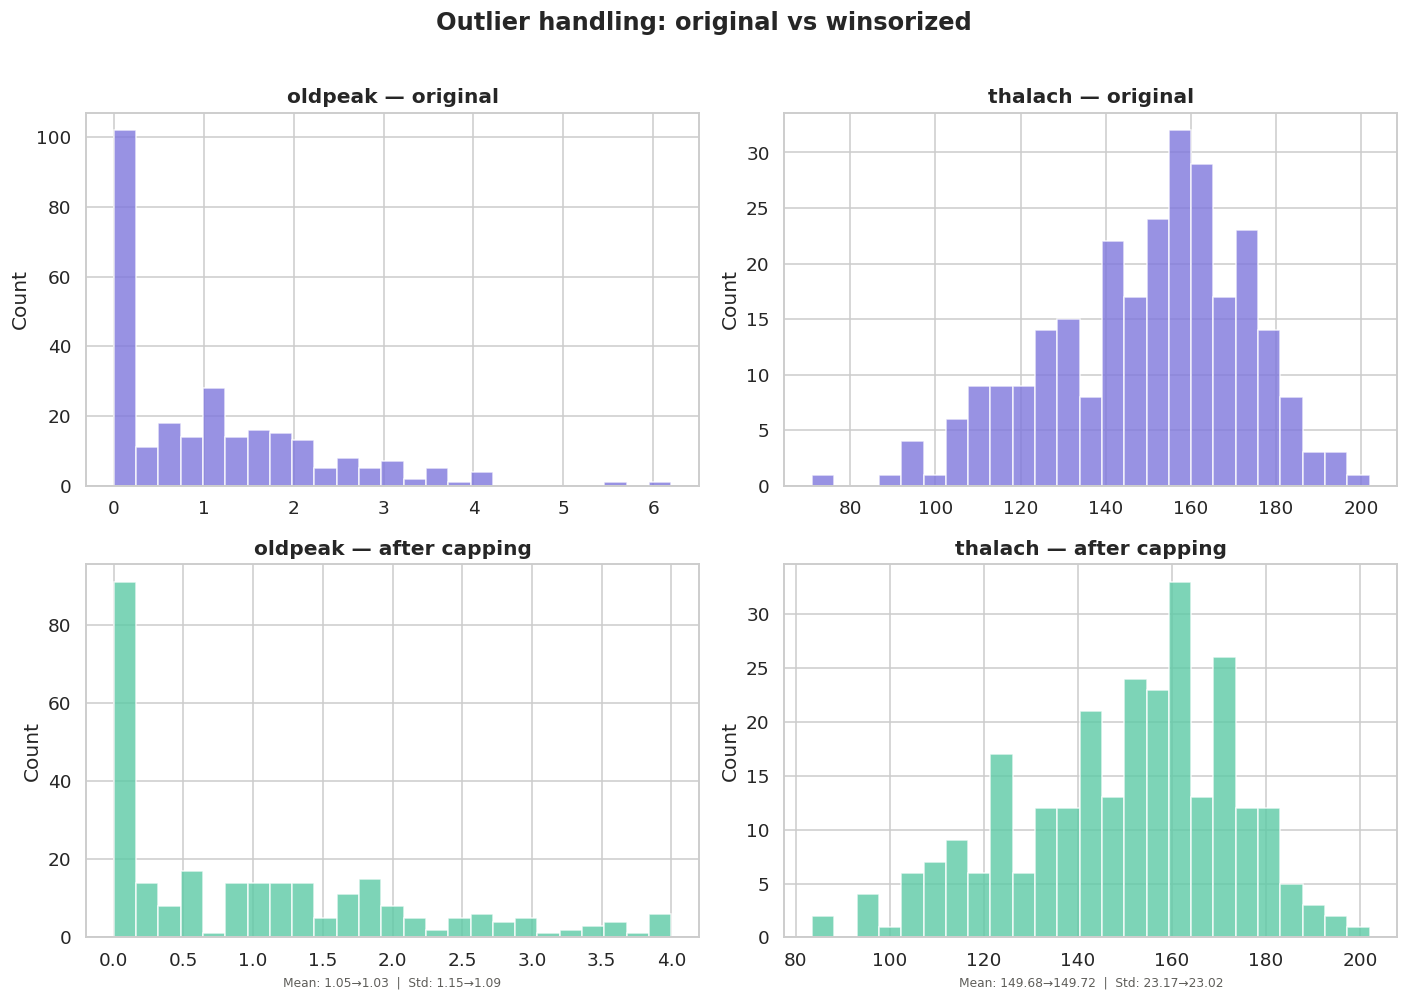


Final X_selected shape: (270, 6)
Sab rows preserved: True


In [87]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for i, col in enumerate(continuous_features):
    ax_orig  = axes[0][i]
    ax_clean = axes[1][i]

    ax_orig.hist(df[col], bins=25, color="#7F77DD", edgecolor="white", alpha=0.8)
    ax_orig.set_title(f"{col} — original", fontweight="bold")
    ax_orig.set_ylabel("Count")

    ax_clean.hist(df_clean[col], bins=25, color="#5DCAA5", edgecolor="white", alpha=0.8)
    ax_clean.set_title(f"{col} — after capping", fontweight="bold")
    ax_clean.set_ylabel("Count")

    orig_std  = df[col].std()
    clean_std = df_clean[col].std()
    orig_mean  = df[col].mean()
    clean_mean = df_clean[col].mean()
    ax_clean.set_xlabel(
        f"Mean: {orig_mean:.2f}→{clean_mean:.2f}  |  Std: {orig_std:.2f}→{clean_std:.2f}",
        fontsize=8, color="#5F5E5A"
    )

# FIX: X_selected update karo df_clean se
X_selected = df_clean[selected_features].copy()
y_target   = df_clean[target_col].copy()

plt.suptitle("Outlier handling: original vs winsorized", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nFinal X_selected shape:", X_selected.shape)
print("Sab rows preserved:", X_selected.shape[0] == df.shape[0])


## ⚙️ Step 4: Preprocessing — Split & Scale

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

continuous_features = ["oldpeak", "thalach"]
binary_features     = ["exang"]
ordinal_features    = ["thal", "ca", "cp"]

X = df_clean[selected_features].copy()
y = df_clean[target_col].copy()

# 85% train+val, 15% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Train+val ko 80/20 → final ~68/17/15a
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42, stratify=y_trainval
)

print("Split sizes:")
print(f"  Train : {X_train.shape[0]} rows  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Val   : {X_val.shape[0]} rows  ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"  Test  : {X_test.shape[0]} rows  ({X_test.shape[0]/len(X)*100:.0f}%)")

print("\nClass balance check (stratify ka kaam):")
for name, yy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"  {name}: {yy.mean()*100:.1f}% disease cases")


Split sizes:
  Train : 183 rows  (68%)
  Val   : 46 rows  (17%)
  Test  : 41 rows  (15%)

Class balance check (stratify ka kaam):
  Train: 44.8% disease cases
  Val: 43.5% disease cases
  Test: 43.9% disease cases


In [89]:
# Scaler SIRF train data pe fit karo — data leakage rokne ke liye
scaler = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_val_scaled[continuous_features]   = scaler.transform(X_val[continuous_features])
X_test_scaled[continuous_features]  = scaler.transform(X_test[continuous_features])

print("Scaling result:")
print(f"\n{'Feature':<12} {'Train Min':>10} {'Train Max':>10} {'Val Min':>8} {'Val Max':>8}")
print("-" * 52)

for col in continuous_features:
    print(f"{col:<12} "          f"{X_train_scaled[col].min():>10.4f} "          f"{X_train_scaled[col].max():>10.4f} "          f"{X_val_scaled[col].min():>8.4f} "          f"{X_val_scaled[col].max():>8.4f}")



Scaling result:

Feature       Train Min  Train Max  Val Min  Val Max
----------------------------------------------------
oldpeak          0.0000     1.0000   0.0000   1.0000
thalach          0.0000     1.0000   0.0970   0.9325


## 🧠 Step 5: SANFIS (Adaptive Neuro-Fuzzy) Training

In [90]:
import torch
import torch.nn as nn
from sanfis import SANFIS
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

print("✅ SANFIS Implementation shuru ho rahi hai...\n")

# ── 1. PyTorch Tensors ───────────────────────────────────────────────────────
X_train_t = torch.tensor(X_train_scaled.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values,        dtype=torch.float32).view(-1, 1)
X_val_t   = torch.tensor(X_val_scaled.values,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val.values,          dtype=torch.float32).view(-1, 1)
X_test_t  = torch.tensor(X_test_scaled.values,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,         dtype=torch.float32).view(-1, 1)

# ── 2. Membership Functions ──────────────────────────────────────────────────
membfuncs = [
    {'function': 'gaussian', 'n_memb': 3,
     'params': {'mu':    {'value': [0.0, 0.5, 1.0], 'trainable': True},
                'sigma': {'value': [1.0, 1.0, 1.0], 'trainable': True}}},
    {'function': 'gaussian', 'n_memb': 4,
     'params': {'mu':    {'value': [0.0, 0.33, 0.66, 1.0], 'trainable': True},
                'sigma': {'value': [1.0, 1.0,  1.0,  1.0], 'trainable': True}}},
    {'function': 'gaussian', 'n_memb': 3,
     'params': {'mu':    {'value': [0.0, 0.5, 1.0], 'trainable': True},
                'sigma': {'value': [1.0, 1.0, 1.0], 'trainable': True}}},
    {'function': 'gaussian', 'n_memb': 3,
     'params': {'mu':    {'value': [0.0, 0.5, 1.0], 'trainable': True},
                'sigma': {'value': [1.0, 1.0, 1.0], 'trainable': True}}},
    {'function': 'gaussian', 'n_memb': 4,
     'params': {'mu':    {'value': [0.0, 0.33, 0.66, 1.0], 'trainable': True},
                'sigma': {'value': [1.0, 1.0,  1.0,  1.0], 'trainable': True}}},
    {'function': 'gaussian', 'n_memb': 2,
     'params': {'mu':    {'value': [0.0, 1.0], 'trainable': True},
                'sigma': {'value': [1.0, 1.0], 'trainable': True}}},
]

# ── 3. Model + Optimizer ─────────────────────────────────────────────────────
model = SANFIS(membfuncs=membfuncs, n_input=6)
print(f"Model trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

loss_function = nn.MSELoss(reduction='mean')
optimizer     = torch.optim.Adam(model.parameters(), lr=0.01)

# ── 4. Training Loop — Loss + Accuracy dono track karo ──────────────────────
epochs   = 100
patience = 10

train_losses, val_losses     = [], []
train_accs,   val_accs       = [], []   # ← YEH NAYA HAI
best_val_loss                = float('inf')
patience_counter             = 0
best_state                   = None

print("\n🚀 Training shuru...\n")
print(f"{'Epoch':>6} | {'Train Loss':>11} | {'Val Loss':>9} | {'Train Acc':>10} | {'Val Acc':>8} | {'Note'}")
print("─" * 68)

for epoch in range(epochs):

    # ── Forward + Backward (train) ──────────────────────────────────────────
    model.train()
    optimizer.zero_grad()
    y_pred_tr = model(X_train_t, X_train_t)
    tr_loss   = loss_function(y_pred_tr, y_train_t)
    tr_loss.backward()
    optimizer.step()

    # ── Validation ──────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val_t, X_val_t)
        v_loss     = loss_function(y_pred_val, y_val_t)

        # ── Accuracy calculate karo (Loss ke sath sath) ─────────────────────
        tr_preds  = (y_pred_tr.detach().numpy()  >= 0.5).astype(int).flatten()
        val_preds = (y_pred_val.numpy()           >= 0.5).astype(int).flatten()

        tr_acc  = accuracy_score(y_train_t.numpy().astype(int).flatten(), tr_preds)
        val_acc = accuracy_score(y_val_t.numpy().astype(int).flatten(),   val_preds)

    # ── Record ──────────────────────────────────────────────────────────────
    train_losses.append(tr_loss.item())
    val_losses.append(v_loss.item())
    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    # ── Early Stopping ──────────────────────────────────────────────────────
    note = ""
    if v_loss.item() < best_val_loss:
        best_val_loss    = v_loss.item()
        patience_counter = 0
        note             = "✓ best"
        best_state       = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  ⏹ Early stopping — epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:>6} | {tr_loss.item():>11.5f} | {v_loss.item():>9.5f} | "
              f"{tr_acc*100:>9.1f}% | {val_acc*100:>7.1f}% | {note}")

# Best model restore
model.load_state_dict(best_state)
print(f"\n✅ Training complete!  Best Val Loss: {best_val_loss:.5f}")
print(f"   Best Val Accuracy  : {max(val_accs)*100:.1f}%")
print(f"   Final Train Acc    : {train_accs[-1]*100:.1f}%")



✅ SANFIS Implementation shuru ho rahi hai...

Model trainable parameters: 6,086

🚀 Training shuru...

 Epoch |  Train Loss |  Val Loss |  Train Acc |  Val Acc | Note
────────────────────────────────────────────────────────────────────
    10 |     0.15815 |   0.11771 |      79.8% |    89.1% | 
    20 |     0.13881 |   0.09200 |      83.1% |    89.1% | ✓ best
    30 |     0.12425 |   0.08194 |      84.7% |    89.1% | ✓ best
    40 |     0.12012 |   0.08011 |      84.2% |    91.3% | 
    50 |     0.11637 |   0.07912 |      85.2% |    89.1% | 
  ⏹ Early stopping — epoch 57

✅ Training complete!  Best Val Loss: 0.07899
   Best Val Accuracy  : 95.7%
   Final Train Acc    : 85.2%


In [91]:
# ───────── SIMPLE FINAL SUMMARY ONLY ───────── #

from sklearn.metrics import accuracy_score

# Test accuracy
with torch.no_grad():
    y_pred_test_raw = model(X_test_t, X_test_t)
    test_preds = (y_pred_test_raw.numpy() >= 0.5).astype(int).flatten()

test_acc_val = accuracy_score(
    y_test_t.numpy().astype(int).flatten(),
    test_preds
)

# Final accuracies
final_train = train_accs[-1] * 100
final_val   = val_accs[-1] * 100
final_test  = test_acc_val * 100

# Gap
gap = abs(final_train - final_val)

# ───────── PRINT SUMMARY ───────── #
print("\n========== FINAL SUMMARY ==========")

print(f"Train Accuracy      : {final_train:.2f}%")
print(f"Validation Accuracy : {final_val:.2f}%")
print(f"Test Accuracy       : {final_test:.2f}%")
print(f"Generalization Gap  : {gap:.2f}%")

# Model status
if gap > 10:
    print("\nModel Status : OVERFIT")

elif final_train < 70:
    print("\nModel Status : UNDERFIT")

else:
    print("\nModel Status : BALANCED")

print("===================================\n")


========== FINAL SUMMARY ==========
Train Accuracy      : 85.25%
Validation Accuracy : 89.13%
Test Accuracy       : 90.24%
Generalization Gap  : 3.88%

Model Status : BALANCED




  🌟 FINAL TEST ACCURACY: 90.2%

Classification Report:
              precision    recall  f1-score   support

  No Disease       1.00      0.83      0.90        23
     Disease       0.82      1.00      0.90        18

    accuracy                           0.90        41
   macro avg       0.91      0.91      0.90        41
weighted avg       0.92      0.90      0.90        41



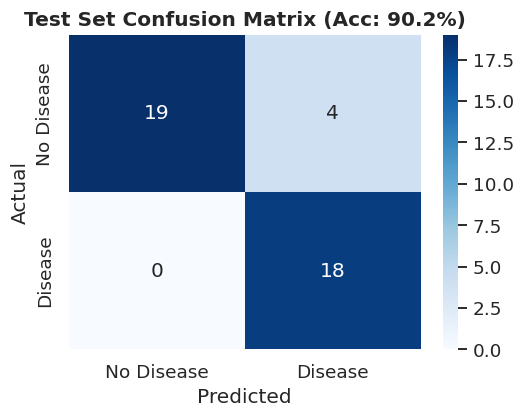

In [94]:
# ── Test Set Evaluation ───────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    y_pred_raw   = model(X_test_t, X_test_t)
    y_pred_class = (y_pred_raw.numpy() >= 0.5).astype(int).flatten()

y_test_np = y_test_t.numpy().astype(int).flatten()
test_acc  = accuracy_score(y_test_np, y_pred_class)

print(f"\n{'='*45}")
print(f"  🌟 FINAL TEST ACCURACY: {test_acc*100:.1f}%")
print(f"{'='*45}\n")
print("Classification Report:")
print(classification_report(y_test_np, y_pred_class,
                             target_names=["No Disease", "Disease"]))

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred_class)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"], ax=ax)
ax.set_title(f"Test Set Confusion Matrix (Acc: {test_acc*100:.1f}%)", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


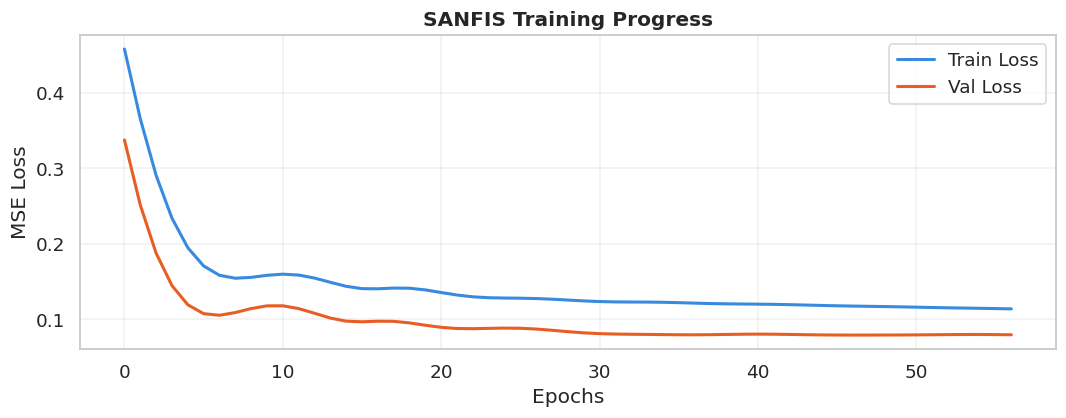

In [92]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color="#378ADD", lw=2)
plt.plot(val_losses,   label='Val Loss',   color="#E85D24", lw=2)
plt.title("SANFIS Training Progress", fontweight="bold")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [98]:
import torch

torch.save(model.state_dict(), "Heart_model_weights.pth")

In [100]:
from google.colab import files
files.download("Heart_model_weights.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>